In [1]:
from c3s_lib import *
import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import cmocean
import base64
from io import BytesIO
import contextily as ctx
from typing import Union, Literal
import os


In [2]:
#Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'

In [3]:
#2.1 Choice of parameter (Tmax, Tmean, Tmin, precipitation)
parameter = "Tmean"

In [5]:
#2.2 Choice of area
bbox = (-110, 18, -95, 32) #Bounding box (-lon, -lat, +lon, +lat)
event_date = datetime(2024, 6, 7)
event_start = event_date - timedelta(days=14)

In [6]:
#2.2.a.i Obtaining climatology (daily values) for period 1950 - event for chosen parameter
climatology_1950_event = DataClient(your_api_key, beacon_cache_url='https://beacon-development.maris.nl').temperature_2m_mean(bbox, (datetime(1951, 1, 1), event_date))
climatology_1950_event = climatology_1950_event.sort_values(by='valid_time')
climatology_1950_event

2025-09-10 11:19:11,730 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


Connected to: https://beacon-development.maris.nl/ server successfully
Connected to: https://beacon-development.maris.nl/ server successfully
Fetching data from beacon cache...
Beacon Bbox: (250.0, 18, 265.0, 32)
Running query: {"from": "era5_daily_mean_2m_temperature", "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "t2m", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 250.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 265.0}, {"column": "latitude", "gt_eq": 18, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": 32}]}, {"column": "valid_time", "gt_eq": "1951-01-01T00:00:00.000000", "lt_eq": "2024-06-07T00:00:00.000000"}], "output": {"format": "parquet"}}
Beacon cache covers time range: 1951-01-01 00:00:00 - 2024-06-07 00:00:00


,longitude,latitude,valid_time,t2m,geometry
0,-110.0,18.00,1951-01-01,23.174316,POINT (-110 18)
2312,-100.0,26.00,1951-01-01,16.865417,POINT (-100 26)
2313,-100.0,26.25,1951-01-01,17.594086,POINT (-100 26.25)
2314,-100.0,26.50,1951-01-01,18.344910,POINT (-100 26.5)
2315,-100.0,26.75,1951-01-01,18.751404,POINT (-100 26.75)
...,...,...,...,...,...
93257779,-105.0,23.50,2024-06-07,19.979370,POINT (-105 23.5)
93257780,-105.0,23.75,2024-06-07,21.217743,POINT (-105 23.75)
93257781,-105.0,24.00,2024-06-07,22.590302,POINT (-105 24)
93257770,-105.0,21.25,2024-06-07,24.647583,POINT (-105 21.25)


In [7]:
#2.2.a.i Selecting climatology (daily values) for event period & 1991-2020 for chosen parameter
climatology_event = climatology_1950_event[(climatology_1950_event['valid_time'] >= event_start) & (climatology_1950_event['valid_time'] <= event_date)]
climatology_1991_2020 = climatology_1950_event[(climatology_1950_event['valid_time'] >= datetime(1991, 1, 1)) & (climatology_1950_event['valid_time'] <= datetime(2020, 12, 31))]

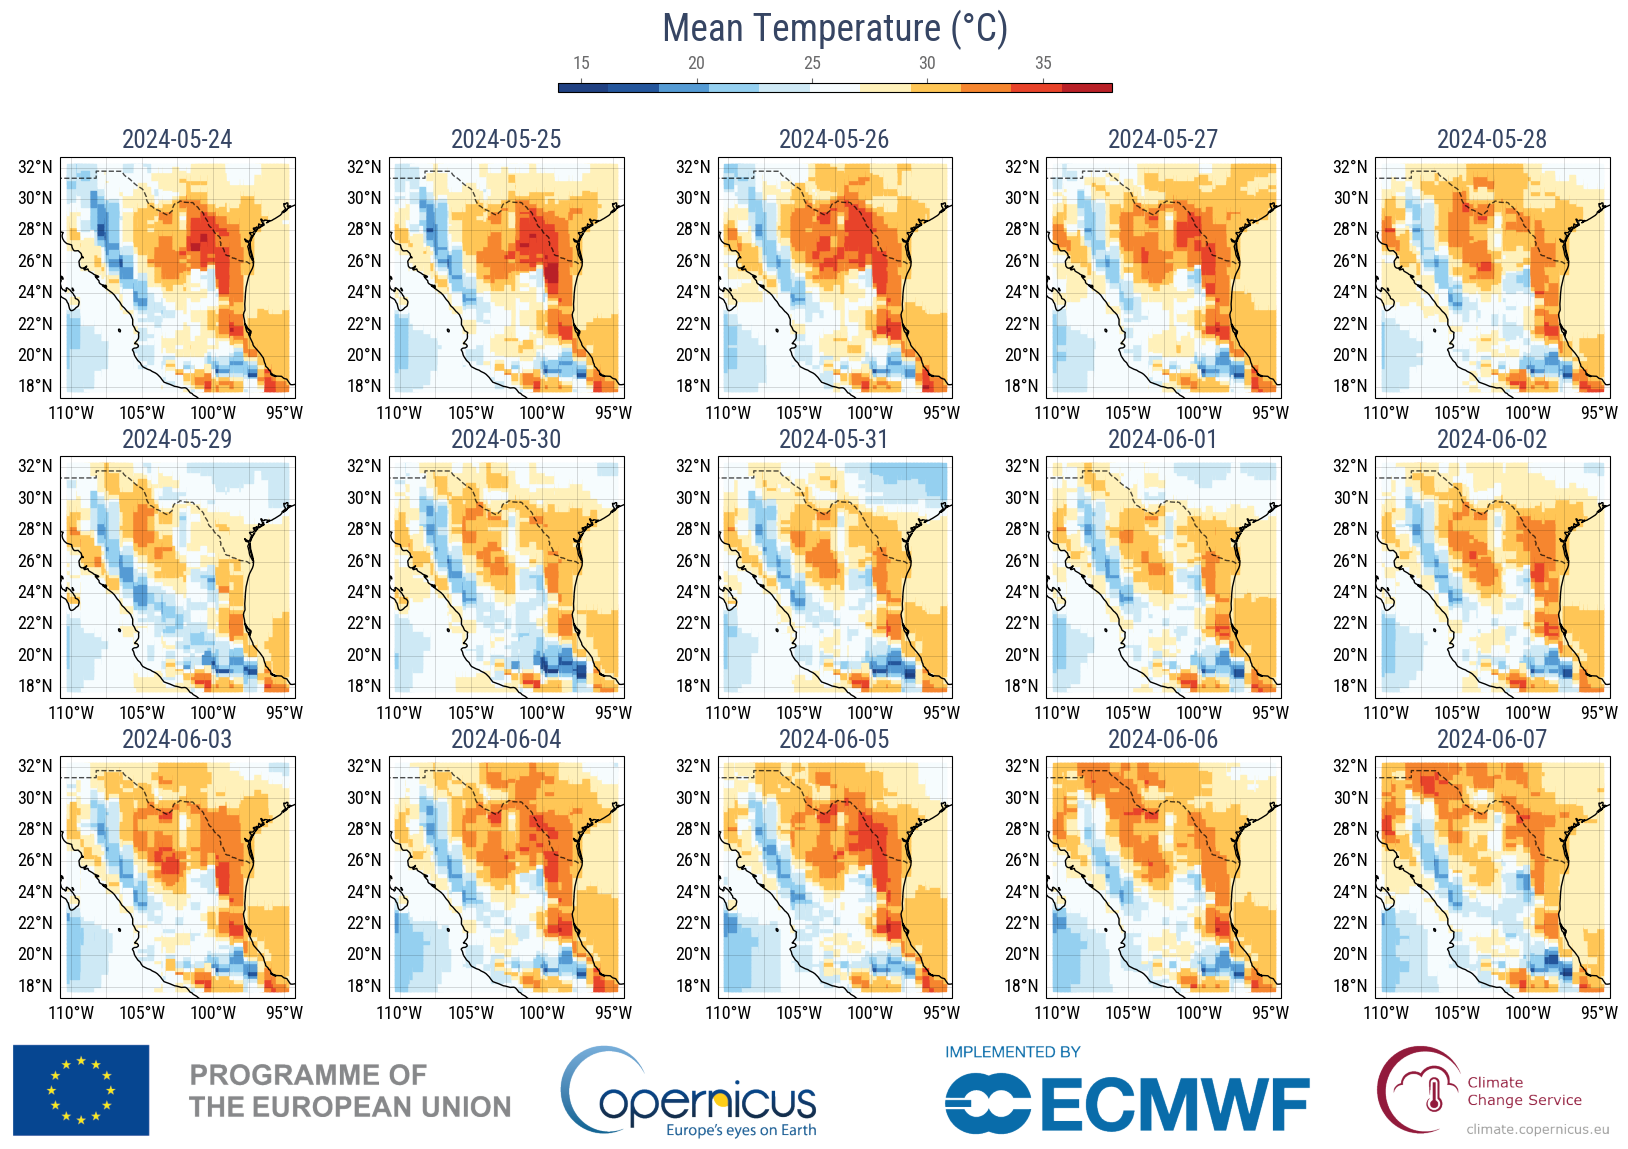

In [ ]:
#2.2.a.i Plotting figure of 15 maps for 15 days up to and including the event of the chosen variable.
fig, axes = subplot_gdf(climatology_event, datetime_col='valid_time', value_col='t2m', ncols=5, legend_title='Mean temperature (°C)')

In [9]:
#2.2.a.ii Calculating the 30-day smoothed climatology for 1991-2020 and slicing out the event days
mean_climatology_1991_2020 = sliding_stat_by_dayofyear(climatology_1991_2020, value_col='t2m', padding=15)
mean_climatology_1991_2020 = gpd.GeoDataFrame(mean_climatology_1991_2020, geometry=gpd.points_from_xy(mean_climatology_1991_2020.longitude, mean_climatology_1991_2020.latitude), crs=climatology_event.crs)
mean_climatology_event = mean_climatology_1991_2020[(mean_climatology_1991_2020['doy'] >= event_start.timetuple().tm_yday) & (mean_climatology_1991_2020['doy'] <= event_date.timetuple().tm_yday)]
mean_climatology_event['valid_time'] = pd.to_datetime('2024', format='%Y') + pd.to_timedelta(mean_climatology_event['doy'] - 1, unit='D')
mean_climatology_event

c:\Users\tjerk\anaconda3\envs\Blue-Cloud\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\tjerk\anaconda3\envs\Blue-Cloud\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\tjerk\anaconda3\envs\Blue-Cloud\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

,longitude,latitude,t2m,doy,geometry,valid_time
500688,-110.0,18.00,23.953434,145,POINT (-110 18),2024-05-24
500689,-110.0,18.25,23.766436,145,POINT (-110 18.25),2024-05-24
500690,-110.0,18.50,23.582802,145,POINT (-110 18.5),2024-05-24
500691,-110.0,18.75,23.381704,145,POINT (-110 18.75),2024-05-24
500692,-110.0,19.00,23.176945,145,POINT (-110 19),2024-05-24
...,...,...,...,...,...,...
552838,-95.0,31.00,26.707762,159,POINT (-95 31),2024-06-07
552839,-95.0,31.25,26.600462,159,POINT (-95 31.25),2024-06-07
552840,-95.0,31.50,26.477228,159,POINT (-95 31.5),2024-06-07
552841,-95.0,31.75,26.372051,159,POINT (-95 31.75),2024-06-07


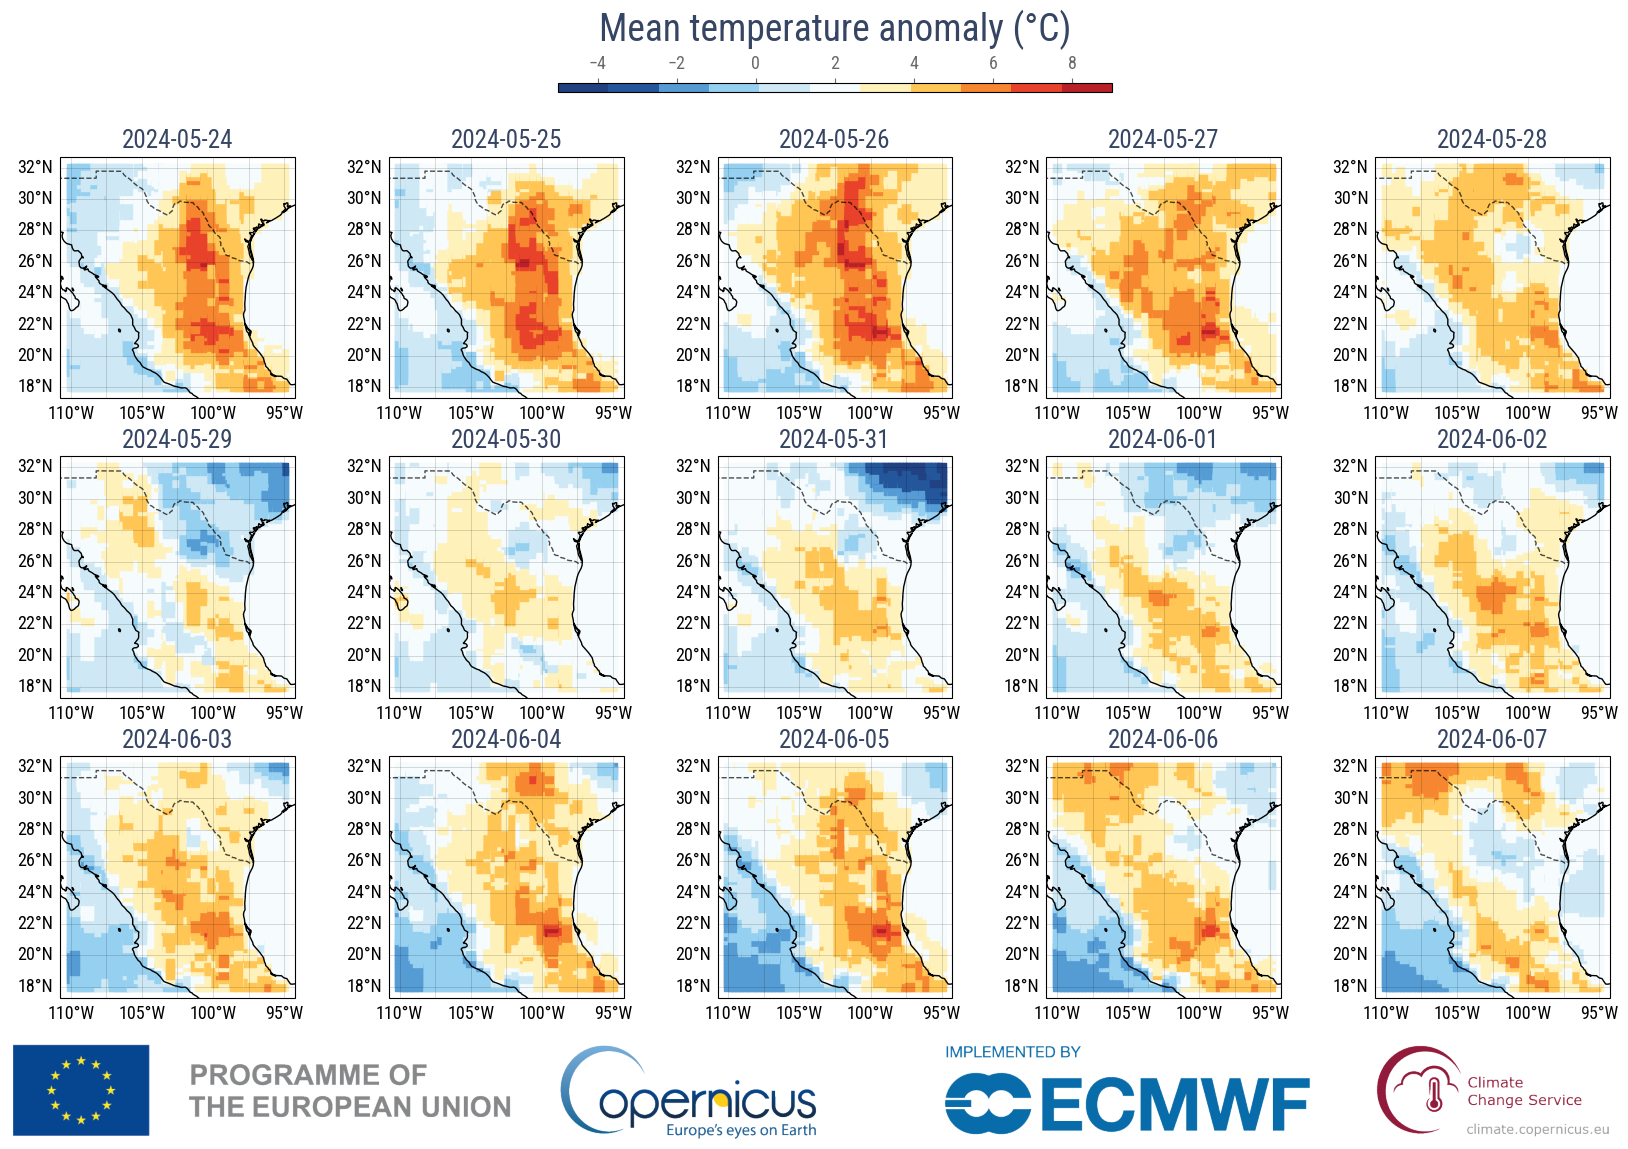

In [11]:
#2.2.a.ii Plotting figure of 15 maps for 15 days up to and including the event of the chosen variable's anomaly with respect to the 1991-2020 30-day running mean of the daily climatology.
event_anomaly = calculate_anomaly(event_gdf=climatology_event,mean_climatology_gdf=mean_climatology_event,value_col='t2m',datetime_col='valid_time',calcation='subtract')
fig, axes = subplot_gdf(event_anomaly,datetime_col='valid_time',value_col='t2m',ncols=5,legend_title='Mean temperature anomaly (°C)')

In [ ]:
#2.2.b Choose one day for the overlay of the regions in steps 2c-2g.
selected_date = datetime(2024, 5, 26)

The region picker will shortly open in your web browser. Please select a region, close the browser tab and return to the notebook when done.
Region Picker started successfully for wraf:
Polling for region selection...
Region selection process done.
Received polygon data:
{"type":"FeatureCollection","features":[{"type":"Feature","properties":{"merge_key":"1"},"geometry":{"type":"Polygon","coordinates":[[[-103.958,27.8333],[-103.917,27.8333],[-103.917,27.6667],[-103.875,27.6667],[-103.875,27.5417],[-103.833,27.5417],[-103.833,27.375],[-103.792,27.375],[-103.792,27.1667],[-103.75,27.1667],[-103.75,27],[-103.708,27],[-103.708,26.9167],[-103.667,26.9167],[-103.667,26.75],[-103.625,26.75],[-103.625,26.625],[-103.542,26.625],[-103.542,26.5833],[-103.5,26.5833],[-103.5,26.5417],[-103.458,26.5417],[-103.458,26.5],[-103.375,26.5],[-103.375,26.4583],[-103.333,26.4583],[-103.333,26.4167],[-103.292,26.4167],[-103.292,26.375],[-103.25,26.375],[-103.25,26.2917],[-103.292,26.2917],[-103.292,26.1667],[

c:\Users\tjerk\anaconda3\envs\Blue-Cloud\Lib\site-packages\xarray\coding\times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
C:\Users\tjerk\AppData\Local\Temp\ipykernel_5152\2230120026.py:17: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")


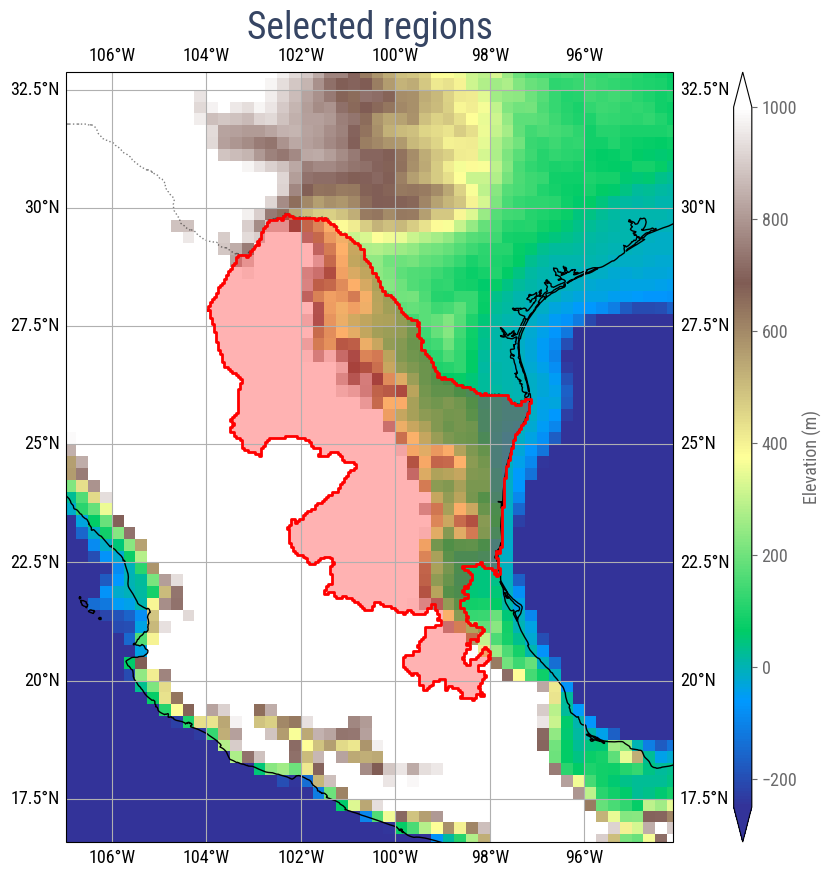

In [13]:
#2.2.c & 2.2.d Define type of region and level by visually inspecting the single map over the event region and select regions to be combined into one spatial event definition.
img_base64_1 = get_base_fig(selected_date, event_anomaly, value_col='t2m')
img_base64_2 = get_base_fig(selected_date, climatology_event, value_col='t2m')
sbbox = ",".join(map(str, bbox))
params = {
    "bbox": sbbox,
    
    "images" : {
        "anomaly": 'data:image/png;base64,'+img_base64_1,
        "event": 'data:image/png;base64,'+img_base64_2
    }
}

result = select_region(regionType='wraf', params=params) # regiontype wraf for temperature, hydrobasin for precipitation
data = json.loads(result)
polygons, coords = data_2_poly(data)
elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")
elevation = wrap_lon(elevation_nc)['data']
fig, ax = plot_poly(polygons, coords, elevation=elevation)

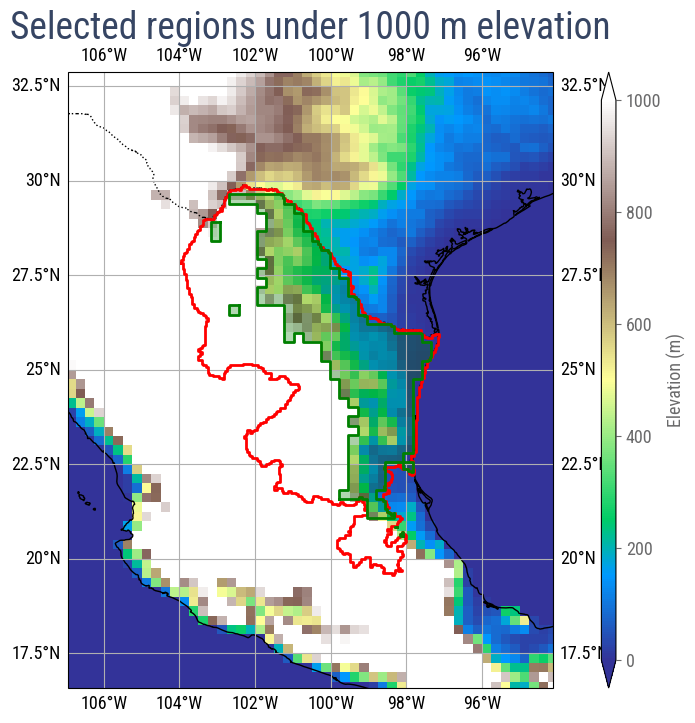

In [14]:
#2.2.e Use topography overlay to decide whether to cut off area above a specified height level
elevation_threshold = 1000  # meters
fig, ax, adjusted_polygons = elevation_region(data, polygons, elevation, elevation_threshold)

In [15]:
#2.2.f-2.2.h Discuss how to incorporate these steps.

In [17]:
#2.3 Save study domain for use in other parts of the software
multipoly = unary_union(adjusted_polygons)
studyregion = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[multipoly])    #is this using the correct CRS?
studyregion.to_file("../data/sf_studyregion.shp")
polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
polygons_gdf.to_file("../data/sf_polygons.shp")

In [18]:
#2.4 Create daily time series of the required variable by averaging over the study domain
climatology_1950_event_studyregion = gpd.overlay(climatology_1950_event, studyregion, how='intersection')
spatialmean_climatology_1950_event_studyregion = climatology_1950_event_studyregion.groupby("valid_time")["t2m"].mean().reset_index()
spatialmean_climatology_1950_event_studyregion.to_xarray().to_netcdf("../data/mean_temperature.nc")
spatialmean_climatology_1950_event_studyregion

,valid_time,t2m
0,1951-01-01,18.048067
1,1951-01-02,20.933586
2,1951-01-03,15.984622
3,1951-01-04,14.335469
4,1951-01-05,16.647875
...,...,...
26817,2024-06-03,31.593693
26818,2024-06-04,32.117180
26819,2024-06-05,32.811573
26820,2024-06-06,31.236914


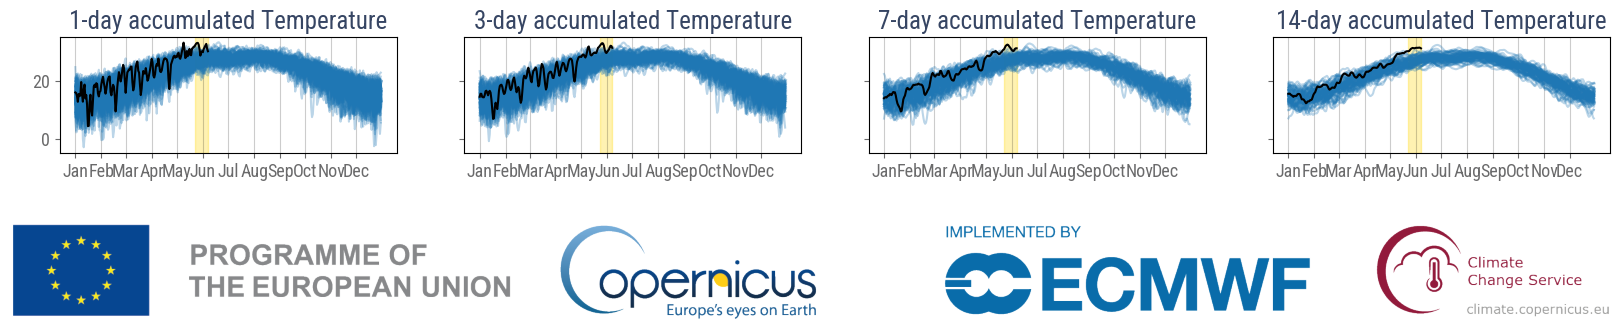

In [76]:
#2.5 Compare n-day accumulations (precipitation) or n-day averages (temperature) for the current year to the seasonal cycle of the same
days = [1, 3, 7, 14] #temperature (t2m): days = [1, 3, 7, 14] & precipitation (tp): days = [1, 3, 5, 10]
rolled_data_list = [n_day_accumulations_gdf(gdf = spatialmean_climatology_1950_event_studyregion, value_col='t2m', datetime_col='valid_time', padding=d, centering=False, method='mean') for d in days]
labelticks = pd.date_range("2000-01-01", "2000-12-31", freq="MS").dayofyear
labels = pd.date_range("2000-01-01", "2000-12-31", freq="MS").strftime("%b")

fig, axs = plot_n_day_accumulations(rolled_data_list,value_col='t2m',parameter="Temperature",event_date=event_date,labelticks=labelticks,labels=labels,days=days,ylimit=None)

In [ ]:
#2.6 Calculate seasonal cycle over years 1991-2020
mean_climatology_1991_2020_studyregion = gpd.overlay(mean_climatology_1991_2020, studyregion, how='intersection')
mean_climatology_1991_2020_studyregion = gpd.GeoDataFrame(mean_climatology_1991_2020_studyregion, geometry=gpd.points_from_xy(mean_climatology_1991_2020_studyregion.longitude, mean_climatology_1991_2020_studyregion.latitude), crs=climatology_event.crs)
mean_climatology_1991_2020_studyregion['valid_time'] = pd.to_datetime('2024', format='%Y') + pd.to_timedelta(mean_climatology_1991_2020_studyregion['doy'] - 1, unit='D')
mean_climatology_1991_2020_studyregion_spatialmean = mean_climatology_1991_2020_studyregion.groupby("valid_time")["t2m"].mean().reset_index()
mean_climatology_1991_2020_studyregion_spatialmean

,valid_time,t2m
0,2024-01-01,14.569913
1,2024-01-02,14.567240
2,2024-01-03,14.555014
3,2024-01-04,14.533158
4,2024-01-05,14.520227
...,...,...
360,2024-12-26,14.765934
361,2024-12-27,14.747066
362,2024-12-28,14.710320
363,2024-12-29,14.636618


In [16]:
def ddplot_timeserie(data, value_col:str, title:str, x_label:str, y_label:str, datetime_col:str='valid_time', 
                   fig_size:tuple=(12,6), dpi:int=100, show_grid:bool=True, line_style:str=':', marker_style:str=None, 
                   draw_style:str='default', label_rotation:int=0, line_width:float=1.5, labelticks:list[str]=None, labels:list[str]=None):
    
    #set font family globally
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)

    ax.plot(data[datetime_col], data[value_col], 
            color='darkblue', 
            linewidth=line_width, 
            linestyle=line_style, 
            drawstyle=draw_style,
            **(marker_style if marker_style is not None else {})
            )

    ax.set_title(label=title)
    ax.set_xlabel(xlabel=x_label, color="#6a6a6b")
    ax.set_ylabel(ylabel=y_label, color="#6a6a6b")

    if labelticks is not None:
        ax.set_xticks(labelticks)
    if labels is not None:
        ax.set_xticklabels(labels)

    if show_grid:
        ax.grid(True)

    # Format x-axis with date labels
    #ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate(rotation=label_rotation)

    # plt.tight_layout()
    # plt.show()
    return fig, ax

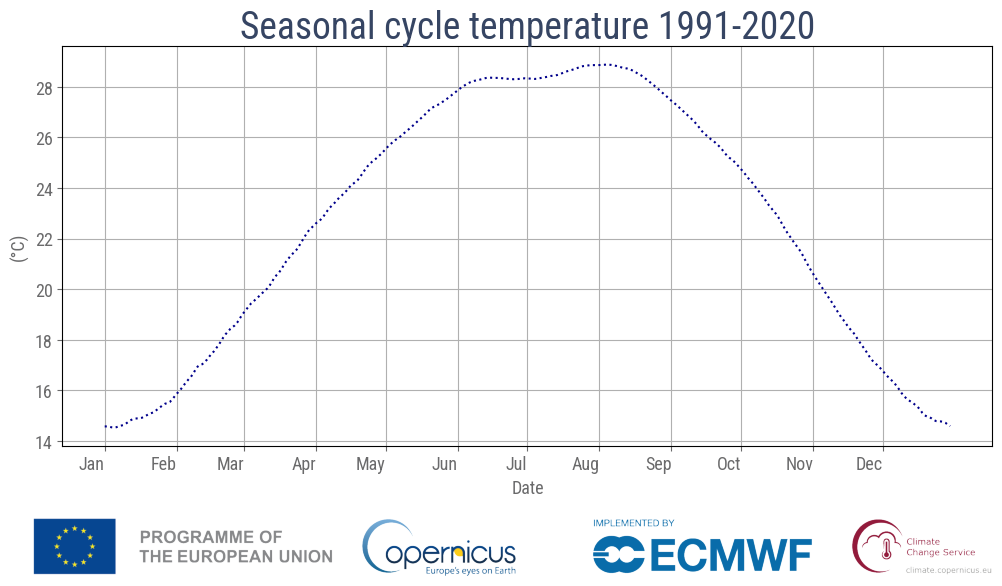

In [26]:
#2.6 Plot seasonal cycle over years 1991-2020
labelticks = pd.date_range("2024-01-01", "2024-12-31", freq="MS")
labels = labelticks.strftime("%b")
fig, ax = plot_timeserie(data=mean_climatology_1991_2020_studyregion_spatialmean, value_col='t2m', title='Seasonal cycle temperature 1991-2020', x_label='Date', y_label='(°C)', line_style=':', labels=labels, labelticks=labelticks)

### 2.7 Decide on the temporal extent  
Use **Step 2.2** and the following considerations:

#### a. As much related to impacts as possible
- e.g. `TXx` (max Temperature 1-day, outdoor workers)  
- e.g. `T3x` (mean Temperature 3-day, people indoors)  
- e.g. Flooding: precipitation averaged over duration or over response time basin  
- e.g. Drought: precipitation values (or soil moisture) averaged over several months or multiple rainy seasons  

#### b. Seasonality
- **OPTIONAL:** Use information from literature review (see also Sec. 6a.), specifically for information on seasonality, that can feed into the choice of event definition.  
- Make use of seasonal cycle plot  
- Restrict to some months if necessary, e.g. if event occurred outside of the usual season or a change in seasonality is suspected  
  - Example: May–June maximum 4-day precipitation  
- Potentially take temperature anomalies rather than absolute values if averaging over months where the seasonal cycle is in transition between peaks and troughs  

#### c. Make use of the plots created in Step 2.5

### 2.8 Make a final decision on the event definition  
Update the output table in the tables document (apart from the last row on return period).

#### a. Write down in the Jupyter Notebook the factors that informed the specific event definition  
Use the following considerations as a guide to single out which aspect of the multifaceted nature of the extreme is chosen for emphasis and communication:

- **Variable:**  
  - `Tmax`, `Tmin`, or `Tmean` – were the daily maxima or the high nighttime minima or both the most defining for the heat event?  

- **Timing:**  
  - Is it the early-season onset of the event that made it anomalous (only) for the time of year, giving locals little time to adjust?  

- **Seasonality:**  
  - Is it specific for a single season only, in case of multiple peaks in the seasonal cycle?  

- **Duration:**  
  - Is it daily record-breaking extremes that will dominate headlines?  
  - Or the long persistence of heat that will also impact indoor conditions, drought, or fire weather, and be felt more than one day of exceptional heat?  

- **Spatial:**  
  - Is the large spatial extent of the event particularly noteworthy over other factors and in comparison to previous similar events in the region?  
  - Or is it that the event location coincides with a densely populated area that makes it particularly noteworthy?  

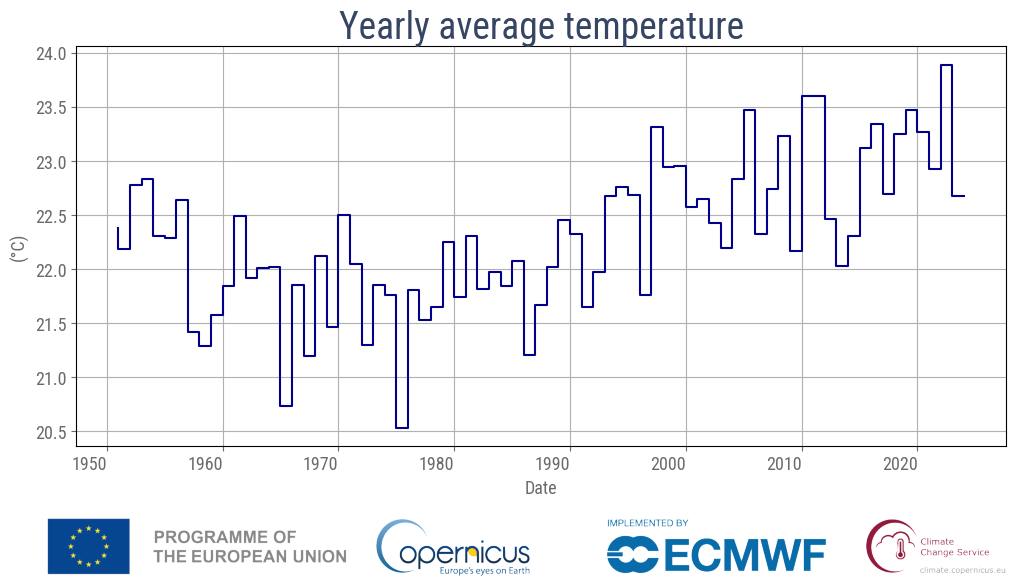

In [27]:
#2.9 Create annual time series based on the event definition
spatialmean_climatology_1950_event_studyregion['valid_time'] = pd.to_datetime(spatialmean_climatology_1950_event_studyregion['valid_time'])
spatialmean_climatology_1950_event_studyregion['year'] = spatialmean_climatology_1950_event_studyregion['valid_time'].dt.year
yearly_avg = spatialmean_climatology_1950_event_studyregion.groupby('year')['t2m'].mean().reset_index()
fig, ax = plot_timeserie(data=yearly_avg, value_col='t2m', datetime_col='year', title='Yearly average temperature', x_label='Date', y_label='(°C)', line_style='-', draw_style='steps')

In [28]:
#2.10 Potentially read in station data time series from .xls

c:\Users\tjerk\anaconda3\envs\Blue-Cloud\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Text(0.5, 1.0, 'Mean temperature anomaly 2024-05-26')

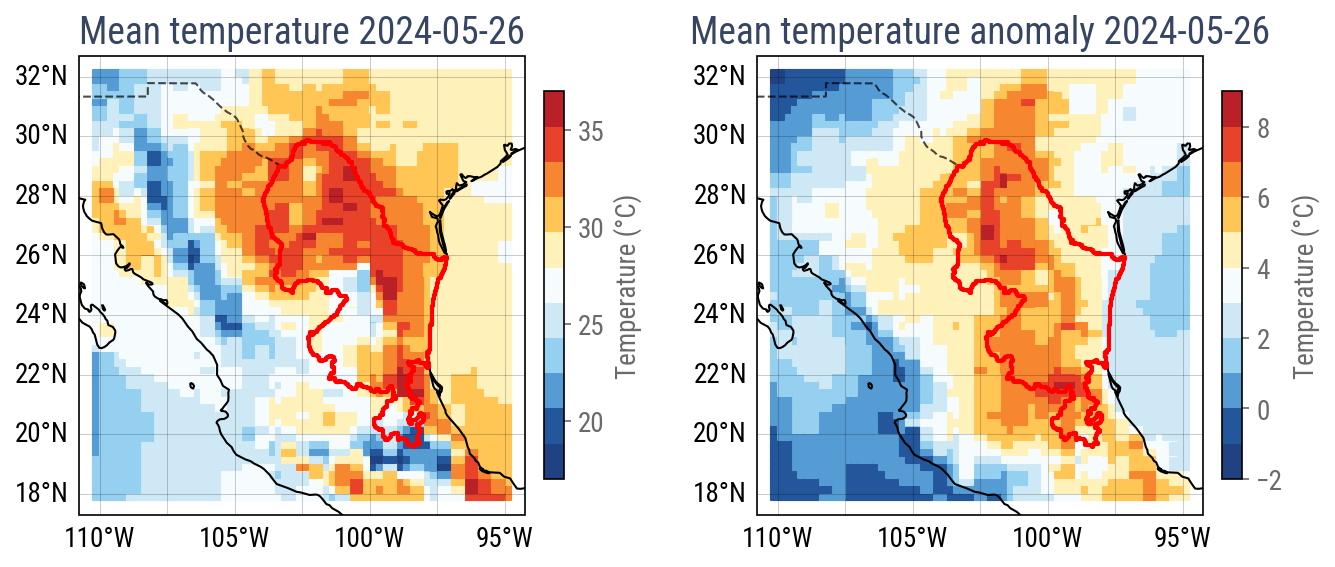

In [44]:
#2.11 Produce a figure of the event "Event Map" (averaged over the temporal definition)
selected_date = datetime(2024, 5, 26)
selected_intersect = climatology_event[(climatology_event['valid_time'] >= selected_date) & (climatology_event['valid_time'] <= selected_date)] #.overlay(poly_gdf, how='intersection')
selected_intersect_anomaly = event_anomaly[(event_anomaly['valid_time'] >= selected_date) & (event_anomaly['valid_time'] <= selected_date)] #.overlay(poly_gdf, how='intersection')
selected_intersect_anomaly['valid_time'] = pd.to_datetime(selected_intersect_anomaly["valid_time"]) + pd.Timedelta(days=1)
selected_intersect = pd.concat([selected_intersect, selected_intersect_anomaly], ignore_index=True)
minx, miny, maxx, maxy = selected_intersect.total_bounds
dx = (maxx - minx) * 0.5   # 10% of width
dy = (maxy - miny) * 0.5   # 10% of height
expanded_extent = [minx - dx, maxx + dx, miny - dy, maxy + dy]

fig, axes = subplot_gdf(
    selected_intersect,
    #title=f"Mean temperature {event_date.strftime('%Y-%m-%d')}",
    legend_title="Temperature (°C)",
    value_col='t2m',
    ncols=2,
    figsize=(10,10),
    flatten_empty_plots=False,
    #extends=expanded_extent,
    dpi=150,
    polygons=polygons,
    shared_colorbar=False,
    add_logos=False
)
axes[0].set_title(f"Mean temperature {selected_date.strftime('%Y-%m-%d')}", fontsize=18)
axes[1].set_title(f"Mean temperature anomaly {selected_date.strftime('%Y-%m-%d')}", fontsize=18)

In [36]:
#2.12 Write a paragraph on the event definition in the scientific report Section 1

In [37]:
#2.13 Produce a set of maps of the meteorological situation for 15 days up to and including the event (waiting for Z500/SLP)

In [38]:
#2.14 Describe the event and meteorology in the scientific report introduction

In [45]:
#2.15 Calculate and save the monthly climatology field to be used for model validation
year = 2024
month = 6  

mean_climatology_1991_2020['valid_time'] = pd.to_datetime('2024', format='%Y') + pd.to_timedelta(mean_climatology_1991_2020['doy'] - 1, unit='D')
month_gdf = mean_climatology_1991_2020[(mean_climatology_1991_2020['valid_time'].dt.year == year) & (mean_climatology_1991_2020['valid_time'].dt.month == month)]
monthly_avg_gdf = month_gdf.groupby(['longitude', 'latitude', 'geometry'], as_index=False)['t2m'].mean()
monthly_avg_gdf

,longitude,latitude,geometry,t2m
0,-110.0,18.00,POINT (-110 18),24.998846
1,-110.0,18.25,POINT (-110 18.25),24.833368
2,-110.0,18.50,POINT (-110 18.5),24.679853
3,-110.0,18.75,POINT (-110 18.75),24.503157
4,-110.0,19.00,POINT (-110 19),24.322914
...,...,...,...,...
3472,-95.0,31.00,POINT (-95 31),27.201265
3473,-95.0,31.25,POINT (-95 31.25),27.126629
3474,-95.0,31.50,POINT (-95 31.5),27.036043
3475,-95.0,31.75,POINT (-95 31.75),26.958748


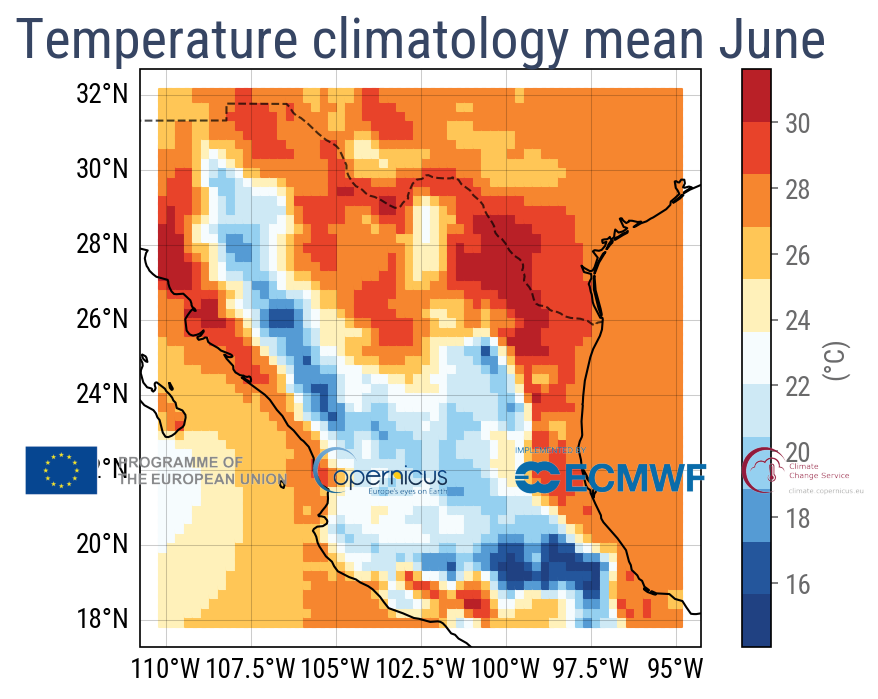

In [51]:
#2.15 Calculate and save the monthly climatology field to be used for model validation
gdf_monthly_avg_gdf = gpd.GeoDataFrame(monthly_avg_gdf,geometry=gpd.points_from_xy(monthly_avg_gdf.longitude, monthly_avg_gdf.latitude), crs=climatology_event.crs)
fig, ax = plot_gdf(gdf_monthly_avg_gdf,title=f"Temperature climatology mean June",legend_title="(°C)",value_col='t2m',dpi=150)